Source: Urista, T. (2019, 29 July). data-analysis. Retrieved from: https://github.com/timurista/data-analysis/tree/master/python-jupyter/Cluster%20Analysis
Companion video available at https://www.youtube.com/watch?v=YIGtalP1mv0

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.cluster import KMeans

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
# CSV file also available at https://raw.githubusercontent.com/timurista/data-analysis/master/python-jupyter/Cluster%20Analysis/3.01.%20Country%20clusters.csv
data = pd.read_csv('3.01. Country clusters.csv')
#data = pd.read_csv("https://raw.githubusercontent.com/timurista/data-analysis/master/python-jupyter/Cluster%20Analysis/3.01.%20Country%20clusters.csv")



(-90.0, 90.0)

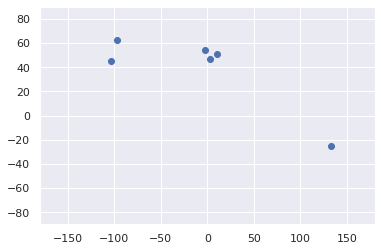

In [3]:
plt.scatter(data['Longitude'], data['Latitude'])
plt.xlim(-180, 180)
plt.ylim(-90, 90)

In [4]:
x = data.iloc[:, 1:3]
x

,Latitude,Longitude
0,44.97,-103.77
1,62.40,-96.80
2,46.75,2.40
3,54.01,-2.53
4,51.15,10.40
5,-25.45,133.11


## Clustering

In [5]:
kmeans = KMeans(3)

In [6]:
kmeans.fit(x)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

## Results

In [7]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

array([0, 0, 1, 1, 1, 2], dtype=int32)

In [8]:
data_with_clusters = data
data_with_clusters['Clusters'] = identified_clusters
data_with_clusters

,Country,Latitude,Longitude,Language,Clusters
0,USA,44.97,-103.77,English,0
1,Canada,62.40,-96.80,English,0
2,France,46.75,2.40,French,1
3,UK,54.01,-2.53,English,1
4,Germany,51.15,10.40,German,1
5,Australia,-25.45,133.11,English,2


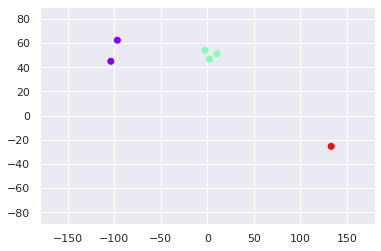

In [9]:
plt.scatter(data['Longitude'], data['Latitude'], c=data_with_clusters['Clusters'],cmap='rainbow')
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.show()

## Encoding and using other variables

In [10]:
data_mapped = data.copy()
data_mapped['Language'] = data_mapped['Language'].map({ 'English':0, 'French':1, 'German': 2})
data_mapped

,Country,Latitude,Longitude,Language,Clusters
0,USA,44.97,-103.77,0,0
1,Canada,62.40,-96.80,0,0
2,France,46.75,2.40,1,1
3,UK,54.01,-2.53,0,1
4,Germany,51.15,10.40,2,1
5,Australia,-25.45,133.11,0,2


In [ ]:
## Select features and Clustering

In [11]:
x = data_mapped.iloc[:, 3:4]
x

,Language
0,0
1,0
2,1
3,0
4,2
5,0


In [12]:
kmeans = KMeans(3)
kmeans.fit(x)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [13]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

array([0, 0, 1, 0, 2, 0], dtype=int32)

In [14]:
data_with_clusters = data_mapped.copy()
data_with_clusters['Clusters'] = identified_clusters
data_with_clusters

,Country,Latitude,Longitude,Language,Clusters
0,USA,44.97,-103.77,0,0
1,Canada,62.40,-96.80,0,0
2,France,46.75,2.40,1,1
3,UK,54.01,-2.53,0,0
4,Germany,51.15,10.40,2,2
5,Australia,-25.45,133.11,0,0


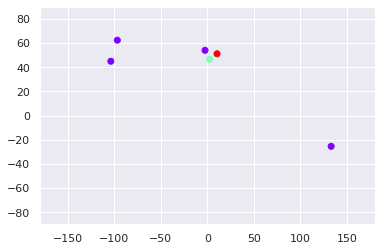

In [15]:
plt.scatter(data['Longitude'], data['Latitude'], c=data_with_clusters['Clusters'],cmap='rainbow')
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.show()

## WCSS
within cluster sum of squares

In [18]:
wcss = []
for i in range(1,7):
    kmeans = KMeans(i)
    kmeans.fit(x)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)

wcss


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  after removing the cwd from sys.path.


[3.5, 0.5, 0.0, 0.0, 0.0, 0.0]

Text(0, 0.5, 'WCSS')

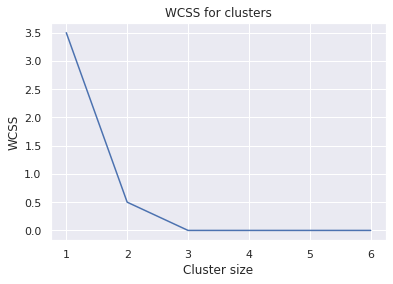

In [19]:
num_clusters = range(1,7)
plt.plot(num_clusters, wcss)
plt.title("WCSS for clusters")
plt.xlabel("Cluster size")
plt.ylabel("WCSS")